In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
books = pd.read_csv("/content/sample_data/Books.csv")
ratings = pd.read_csv("/content/sample_data/Ratings.csv")
users = pd.read_csv("/content/sample_data/Users.csv")
books.sample()

/tmp/ipython-input-4146315648.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("/content/sample_data/Books.csv")


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
49726,0152956026,Where the Broken Heart Still Beats: The Story ...,Carolyn Meyer,1992,Gulliver Books Paperbacks,http://images.amazon.com/images/P/0152956026.0...,http://images.amazon.com/images/P/0152956026.0...,http://images.amazon.com/images/P/0152956026.0...


In [5]:
books = books[["ISBN","Book-Title", "Book-Author", "Publisher", "Year-Of-Publication", "Image-URL-L"]]
books.sample(10)

,ISBN,Book-Title,Book-Author,Publisher,Year-Of-Publication,Image-URL-L
171416,0808598988,In Search of Our Mother's Garden,Alice Walker,Sagebrush Bound,1999,http://images.amazon.com/images/P/0808598988.0...
35576,0553284126,Season of Swans,Celeste De Blasis,Bantam Books,1990,http://images.amazon.com/images/P/0553284126.0...
40556,0451202538,Hangman,Michael Slade,Signet Book,2001,http://images.amazon.com/images/P/0451202538.0...
134228,096796752X,Boston Boy: Growing Up With Jazz and Other Reb...,Nat Hentoff,Paul Dry Books,2001,http://images.amazon.com/images/P/096796752X.0...
192907,0767908287,"The Dig Tree : A True Story of Bravery, Insani...",SARAH MURGATROYD,Broadway,2002,http://images.amazon.com/images/P/0767908287.0...
101979,1569246777,The Glucose Revolution Pocket Guide to Losing ...,Thomas M. S. Wolever,Marlowe &amp; Company,2000,http://images.amazon.com/images/P/1569246777.0...
238079,038546813X,Winning With the American Quarter Horse (Doubl...,Don Burt,Bantam Dell Pub Group,1996,http://images.amazon.com/images/P/038546813X.0...
143360,0811821048,Learn to Relax : A Practical Guide to Easing T...,Mike George,Chronicle Books Llc,1998,http://images.amazon.com/images/P/0811821048.0...
92818,0764502050,HTML 4 (Dummies 101 Series),Deborah S. Ray,For Dummies,1998,http://images.amazon.com/images/P/0764502050.0...
257830,3150039126,Bergkristall,Stifter,"Philipp Reclam, Jun Verlag GmbH",0,http://images.amazon.com/images/P/3150039126.0...


Rename column names:

In [6]:
books.rename(columns= {"Book-Title" : "title", "Book-Author":"author", "Year-Of-Publication": "year",
                       "Publisher":"publisher", "Image-URL-L":"image_url"}, inplace= True)
books

,ISBN,title,author,publisher,year,image_url
0,0195153448,Classical Mythology,Mark P. O. Morford,Oxford University Press,2002,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,2001,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,HarperPerennial,1991,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,Farrar Straus Giroux,1999,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,W. W. Norton &amp; Company,1999,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,Random House Childrens Pub (Mm),1988,http://images.amazon.com/images/P/0440400988.0...
271356,0525447644,From One to One Hundred,Teri Sloat,Dutton Books,1991,http://images.amazon.com/images/P/0525447644.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,HarperSanFrancisco,2004,http://images.amazon.com/images/P/006008667X.0...
271358,0192126040,Republic (World's Classics),Plato,Oxford University Press,1996,http://images.amazon.com/images/P/0192126040.0...


In [7]:
users.rename(columns={"User-ID":"user_id", "Location":"location", "Age":"age"}, inplace= True)
users.sample(10)

,user_id,location,age
218287,218288,"rochester, new york, usa",47.0
60905,60906,"london, n/a, united kingdom",28.0
42272,42273,"mill valley, california, usa",34.0
212560,212561,"milan, lombardia, italy",20.0
53890,53891,"roma, lazio, italy",NaN
192014,192015,"melbourne, victoria, australia",14.0
117612,117613,"philadelphia, pennsylvania, usa",38.0
275407,275408,"springfield, missouri, usa",NaN
224240,224241,"hamburg, hamburg, germany",NaN
271365,271366,"fremantle, western australia, australia",52.0


In [8]:
ratings.rename(columns={"User-ID":"user_id" , "Book-Rating": "book_rating" }, inplace= True)

In [9]:
ratings

,user_id,ISBN,book_rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10
1149778,276721,0590442449,10


Which user is rating the most books?

In [10]:
import seaborn as sns
group_by_users = ratings["user_id"].value_counts().sort_values(ascending=False)
group_by_users

,count
user_id,
11676,13602
198711,7550
153662,6109
98391,5891
35859,5850
...,...
172246,1
172251,1
172258,1


In [11]:
complete_df = pd.merge(books, ratings, on= "ISBN").merge(users, on = "user_id")
complete_df

,ISBN,title,author,publisher,year,image_url,user_id,book_rating,location,age
0,0195153448,Classical Mythology,Mark P. O. Morford,Oxford University Press,2002,http://images.amazon.com/images/P/0195153448.0...,2,0,"stockton, california, usa",18.0
1,0002005018,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,2001,http://images.amazon.com/images/P/0002005018.0...,8,5,"timmins, ontario, canada",NaN
2,0002005018,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,2001,http://images.amazon.com/images/P/0002005018.0...,11400,0,"ottawa, ontario, canada",49.0
3,0002005018,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,2001,http://images.amazon.com/images/P/0002005018.0...,11676,8,"n/a, n/a, n/a",NaN
4,0002005018,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,2001,http://images.amazon.com/images/P/0002005018.0...,41385,0,"sudbury, ontario, canada",NaN
...,...,...,...,...,...,...,...,...,...,...
1031131,0440400988,There's a Bat in Bunk Five,Paula Danziger,Random House Childrens Pub (Mm),1988,http://images.amazon.com/images/P/0440400988.0...,276463,7,"providence, rhode island, usa",26.0
1031132,0525447644,From One to One Hundred,Teri Sloat,Dutton Books,1991,http://images.amazon.com/images/P/0525447644.0...,276579,4,"orem, utah, usa",12.0
1031133,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,HarperSanFrancisco,2004,http://images.amazon.com/images/P/006008667X.0...,276680,0,"hopewell junction, new york, usa",55.0
1031134,0192126040,Republic (World's Classics),Plato,Oxford University Press,1996,http://images.amazon.com/images/P/0192126040.0...,276680,0,"hopewell junction, new york, usa",55.0


POPULARITY BASED RECOMMENDOR SYSTEM:

In [12]:
avg_ratings_per_book = complete_df.groupby("title").agg({"user_id": "count" , "book_rating":"mean"})
avg_ratings_per_book.rename(columns={"book_rating":"avg_rating", "user_id": "num_of_ratings"}, inplace= True)
avg_ratings_per_book

,num_of_ratings,avg_rating
title,,
"A Light in the Storm: The Civil War Diary of Amelia Martin, Fenwick Island, Delaware, 1861 (Dear America)",4,2.250000
Always Have Popsicles,1,0.000000
Apple Magic (The Collector's series),1,0.000000
"Ask Lily (Young Women of Faith: Lily Series, Book 5)",1,8.000000
Beyond IBM: Leadership Marketing and Finance for the 1990s,1,0.000000
...,...,...
Ã?Â?lpiraten.,2,0.000000
Ã?Â?rger mit Produkt X. Roman.,4,5.250000
Ã?Â?sterlich leben.,1,7.000000


,title,num_of_ratings,avg_rating
55,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804
53,Harry Potter and the Goblet of Fire (Book 4),387,5.824289
56,Harry Potter and the Sorcerer's Stone (Book 1),278,5.737410
54,Harry Potter and the Order of the Phoenix (Boo...,347,5.501441
52,Harry Potter and the Chamber of Secrets (Book 2),556,5.183453
...,...,...,...
173,Vinegar Hill (Oprah's Book Club (Paperback)),265,2.245283
180,Whispers,286,2.199301
88,Presumed Innocent,294,2.139456
66,Isle of Dogs,288,2.000000


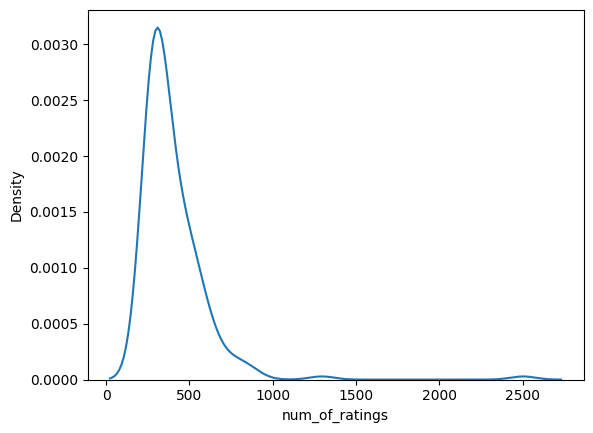

In [13]:
avg_ratings_per_book = avg_ratings_per_book[avg_ratings_per_book['num_of_ratings'] >= 250].reset_index().sort_values(by="avg_rating", ascending=False)
sns.kdeplot(avg_ratings_per_book["num_of_ratings"])
avg_ratings_per_book

Since for popularity books, we only want the top 50 books.

In [14]:
popular_books = avg_ratings_per_book.head(50)
popular_books = pd.merge(popular_books, books, how="left", on="title").drop_duplicates("title")

COLLABORATIVE FILTERING BASED RECOMMENDOR SYSTEM:

Users who voted:

,user_id,count
0,11676,11144
1,198711,6456
2,153662,5814
3,98391,5779
4,35859,5646
...,...,...
92101,269485,1
92102,243994,1
92103,243884,1
92104,243757,1


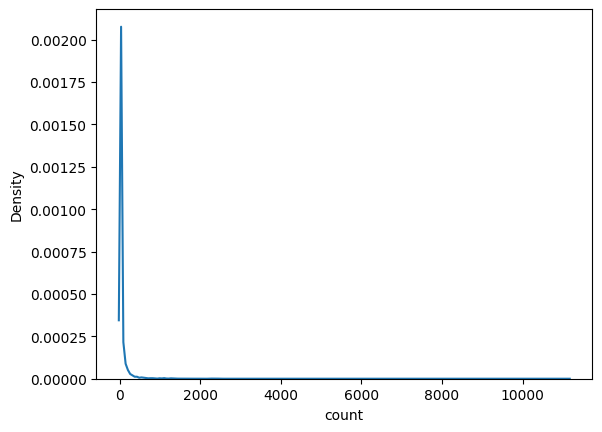

In [15]:
users_who_rated = complete_df["user_id"].value_counts().reset_index()

sns.kdeplot(users_who_rated["count"])
users_who_rated

We will only consider users who voted atleast 200 books. because it will reduce variance then.

In [16]:
users_who_rated_200_books = users_who_rated[users_who_rated["count"] >= 200]["user_id"]
userdetails_with_min_ratings_200 = complete_df[complete_df["user_id"].isin(users_who_rated_200_books)]
userdetails_with_min_ratings_200

,ISBN,title,author,publisher,year,image_url,user_id,book_rating,location,age
3,0002005018,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,2001,http://images.amazon.com/images/P/0002005018.0...,11676,8,"n/a, n/a, n/a",NaN
6,0002005018,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,2001,http://images.amazon.com/images/P/0002005018.0...,85526,0,"victoria, british columbia, canada",36.0
7,0002005018,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,2001,http://images.amazon.com/images/P/0002005018.0...,96054,0,"ottawa, ontario, canada",29.0
10,0002005018,Clara Callan,Richard Bruce Wright,HarperFlamingo Canada,2001,http://images.amazon.com/images/P/0002005018.0...,177458,0,"ottawa, ontario, canada",29.0
21,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,Farrar Straus Giroux,1999,http://images.amazon.com/images/P/0374157065.0...,110912,10,"milpitas, california, usa",36.0
...,...,...,...,...,...,...,...,...,...,...
1031124,0231128444,Slow Food(The Case For Taste),Carlo Petrini,Columbia University Press,2003,http://images.amazon.com/images/P/0231128444.0...,275970,0,"pittsburgh, pennsylvania, usa",46.0
1031125,0520242335,Strong Democracy : Participatory Politics for ...,Benjamin R. Barber,University of California Press,2004,http://images.amazon.com/images/P/0520242335.0...,275970,0,"pittsburgh, pennsylvania, usa",46.0
1031126,0762412119,"Burpee Gardening Cyclopedia: A Concise, Up to ...",Allan Armitage,Running Press Book Publishers,2002,http://images.amazon.com/images/P/0762412119.0...,275970,0,"pittsburgh, pennsylvania, usa",46.0
1031127,1582380805,Tropical Rainforests: 230 Species in Full Colo...,"Allen M., Ph.D. Young",Golden Guides from St. Martin's Press,2001,http://images.amazon.com/images/P/1582380805.0...,275970,0,"pittsburgh, pennsylvania, usa",46.0


We also need to consider only books with minimum 50 users_ratings

In [17]:
y = userdetails_with_min_ratings_200
booktitles_with_min50_user_ratings = userdetails_with_min_ratings_200.groupby("title").count()["user_id"] >= 50
booktitles_with_min50_user_ratings
final_ratings = y[y["title"].isin(booktitles_with_min50_user_ratings[booktitles_with_min50_user_ratings].index)]
final_ratings.drop_duplicates()

,ISBN,title,author,publisher,year,image_url,user_id,book_rating,location,age
31,0399135782,The Kitchen God's Wife,Amy Tan,Putnam Pub Group,1991,http://images.amazon.com/images/P/0399135782.0...,11676,9,"n/a, n/a, n/a",NaN
33,0399135782,The Kitchen God's Wife,Amy Tan,Putnam Pub Group,1991,http://images.amazon.com/images/P/0399135782.0...,36836,0,"raleigh, north carolina, usa",56.0
34,0399135782,The Kitchen God's Wife,Amy Tan,Putnam Pub Group,1991,http://images.amazon.com/images/P/0399135782.0...,46398,9,"san antonio, texas, usa",37.0
38,0399135782,The Kitchen God's Wife,Amy Tan,Putnam Pub Group,1991,http://images.amazon.com/images/P/0399135782.0...,113270,0,"evanston, illinois, usa",25.0
39,0399135782,The Kitchen God's Wife,Amy Tan,Putnam Pub Group,1991,http://images.amazon.com/images/P/0399135782.0...,113519,0,"pleasanton, california, usa",NaN
...,...,...,...,...,...,...,...,...,...,...
1028414,1878702831,Echoes,Nancy Morse,Meteor Publishing Corporation,1992,http://images.amazon.com/images/P/1878702831.0...,238781,0,"yucca valley, california, usa",51.0
1028600,0394429869,I Know Why the Caged Bird Sings,Maya Angelou,Random House,1996,http://images.amazon.com/images/P/0394429869.0...,239594,8,"leuven, vlaams-brabant, belgium",28.0
1028602,0449001164,The Promise,CHAIM POTOK,Ballantine Books,1997,http://images.amazon.com/images/P/0449001164.0...,239594,7,"leuven, vlaams-brabant, belgium",28.0
1028815,0743527631,The Pillars of the Earth,Ken Follett,Encore,2002,http://images.amazon.com/images/P/0743527631.0...,240144,0,"muskego, wisconsin, usa",34.0


In [ ]:
# Now we want to create a table with books as rows and users as columns and ratings as entries

In [18]:
pivot_table = final_ratings.pivot_table(index="title", columns="user_id", values ="book_rating")
pivot_table.isnull().sum()
pivot_table.fillna(0, inplace=True)
pivot_table

user_id,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Now eac book is a vector in 810 dimensional space. And we want to see the similarities between vectors and for that we will calculate the Euclidean distances between them.

In [19]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_scores = cosine_similarity(pivot_table)
similarity_scores

array([[1.        , 0.0999137 , 0.01189468, ..., 0.11799012, 0.07158663,
        0.04205081],
       [0.0999137 , 1.        , 0.2364573 , ..., 0.07446129, 0.16773875,
        0.14263397],
       [0.01189468, 0.2364573 , 1.        , ..., 0.04558758, 0.04938579,
        0.10796119],
       ...,
       [0.11799012, 0.07446129, 0.04558758, ..., 1.        , 0.07085128,
        0.0196177 ],
       [0.07158663, 0.16773875, 0.04938579, ..., 0.07085128, 1.        ,
        0.10602962],
       [0.04205081, 0.14263397, 0.10796119, ..., 0.0196177 , 0.10602962,
        1.        ]])

In [20]:
def recommend(book_name):
  # fetch index of book:
  book_index = np.where(pivot_table.index == book_name)[0][0]

  # enumerate to get index besides the score. lambda dunction to sort by scores otherwise it sorts by index
  # removing the first one because the first one is this book itself hence it's similarity with itself = 1
  similarity_scores_for_this_book = sorted(list(enumerate(similarity_scores[book_index])), key = lambda x: x[1], reverse=True)[1:]

  # Since we only want top 10 most similar:
  similar_10 = similarity_scores_for_this_book[:10]
  similar_books = []
  for index in similar_10:
    similar_books.append(pivot_table.index[index[0]])

  return similar_books

In [27]:
recommend("The Witness")

['Secrets',
 'Exclusive',
 'Message from Nam',
 'Kaleidoscope',
 'Remember Me',
 'The Long Road Home',
 'Anne of Avonlea (Anne of Green Gables Novels (Paperback))',
 'Montana Sky',
 'Unspeakable',
 'Fine Things']

In [28]:
import pickle

# Save pivot table
with open("pivot_table.pkl", "wb") as f:
    pickle.dump(pivot_table, f)

# Save similarity matrix
with open("similarity.pkl", "wb") as f:
    pickle.dump(similarity_scores, f)

# Save books dataframe (title + image + author)
books_small = books[["title", "author", "image_url"]].drop_duplicates()

with open("books.pkl", "wb") as f:
    pickle.dump(books_small, f)

# Save popular books (top 50 already computed)
with open("popular_books.pkl", "wb") as f:
    pickle.dump(popular_books, f)
